### Preparando o ambiente

In [270]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [271]:
df = pd.read_csv("data/radiomic_data_binary.csv")

# EDA

In [272]:
# Vendo as informações do dataset
df.info()
classes = df['class']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Columns: 116 entries, diagnostics_Versions_PyRadiomics to class
dtypes: float64(96), int64(2), object(18)
memory usage: 1.8+ MB


In [273]:
# Vendo todas as colunas do dataset
print(df.columns.to_list())

['diagnostics_Versions_PyRadiomics', 'diagnostics_Versions_Numpy', 'diagnostics_Versions_SimpleITK', 'diagnostics_Versions_PyWavelet', 'diagnostics_Versions_Python', 'diagnostics_Configuration_Settings', 'diagnostics_Configuration_EnabledImageTypes', 'diagnostics_Image-original_Hash', 'diagnostics_Image-original_Dimensionality', 'diagnostics_Image-original_Spacing', 'diagnostics_Image-original_Size', 'diagnostics_Image-original_Mean', 'diagnostics_Image-original_Minimum', 'diagnostics_Image-original_Maximum', 'diagnostics_Mask-original_Hash', 'diagnostics_Mask-original_Spacing', 'diagnostics_Mask-original_Size', 'diagnostics_Mask-original_BoundingBox', 'diagnostics_Mask-original_VoxelNum', 'diagnostics_Mask-original_VolumeNum', 'diagnostics_Mask-original_CenterOfMassIndex', 'diagnostics_Mask-original_CenterOfMass', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange'

In [274]:
columns = [
    'diagnostics_Versions_PyRadiomics', 'diagnostics_Versions_Numpy', 'diagnostics_Versions_SimpleITK', 
    'diagnostics_Versions_PyWavelet', 'diagnostics_Versions_Python', 'diagnostics_Configuration_Settings', 
    'diagnostics_Configuration_EnabledImageTypes', 'diagnostics_Image-original_Hash', 'diagnostics_Image-original_Dimensionality', 
    'diagnostics_Image-original_Spacing', 'diagnostics_Image-original_Size', 'diagnostics_Image-original_Mean', 
    'diagnostics_Image-original_Minimum', 'diagnostics_Image-original_Maximum', 'diagnostics_Mask-original_Hash', 
    'diagnostics_Mask-original_Spacing', 'diagnostics_Mask-original_Size', 'diagnostics_Mask-original_BoundingBox', 
    'diagnostics_Mask-original_VoxelNum', 'diagnostics_Mask-original_VolumeNum', 'diagnostics_Mask-original_CenterOfMassIndex', 
    'diagnostics_Mask-original_CenterOfMass', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 
    'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 
    'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean', 'original_firstorder_Median', 
    'original_firstorder_Minimum', 'original_firstorder_Range', 'original_firstorder_RobustMeanAbsoluteDeviation', 'original_firstorder_RootMeanSquared', 
    'original_firstorder_Skewness', 'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity', 'original_firstorder_Variance', 
    'original_glcm_Autocorrelation', 'original_glcm_ClusterProminence', 'original_glcm_ClusterShade', 'original_glcm_ClusterTendency', 
    'original_glcm_Contrast', 'original_glcm_Correlation', 'original_glcm_DifferenceAverage', 'original_glcm_DifferenceEntropy', 
    'original_glcm_DifferenceVariance', 'original_glcm_Id', 'original_glcm_Idm', 'original_glcm_Idmn', 'original_glcm_Idn', 
    'original_glcm_Imc1', 'original_glcm_Imc2', 'original_glcm_InverseVariance', 'original_glcm_JointAverage', 'original_glcm_JointEnergy', 
    'original_glcm_JointEntropy', 'original_glcm_MCC', 'original_glcm_MaximumProbability', 'original_glcm_SumAverage', 'original_glcm_SumEntropy', 
    'original_glcm_SumSquares', 'original_gldm_DependenceEntropy', 'original_gldm_DependenceNonUniformity', 'original_gldm_DependenceNonUniformityNormalized', 
    'original_gldm_DependenceVariance', 'original_gldm_GrayLevelNonUniformity', 'original_gldm_GrayLevelVariance', 'original_gldm_HighGrayLevelEmphasis', 
    'original_gldm_LargeDependenceEmphasis', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 
    'original_gldm_LowGrayLevelEmphasis', 'original_gldm_SmallDependenceEmphasis', 'original_gldm_SmallDependenceHighGrayLevelEmphasis', 
    'original_gldm_SmallDependenceLowGrayLevelEmphasis', 'original_glrlm_GrayLevelNonUniformity', 'original_glrlm_GrayLevelNonUniformityNormalized', 
    'original_glrlm_GrayLevelVariance', 'original_glrlm_HighGrayLevelRunEmphasis', 'original_glrlm_LongRunEmphasis', 'original_glrlm_LongRunHighGrayLevelEmphasis', 
    'original_glrlm_LongRunLowGrayLevelEmphasis', 'original_glrlm_LowGrayLevelRunEmphasis', 'original_glrlm_RunEntropy', 'original_glrlm_RunLengthNonUniformity', 
    'original_glrlm_RunLengthNonUniformityNormalized', 'original_glrlm_RunPercentage', 'original_glrlm_RunVariance', 'original_glrlm_ShortRunEmphasis', 
    'original_glrlm_ShortRunHighGrayLevelEmphasis', 'original_glrlm_ShortRunLowGrayLevelEmphasis', 'original_glszm_GrayLevelNonUniformity', 
    'original_glszm_GrayLevelNonUniformityNormalized', 'original_glszm_GrayLevelVariance', 'original_glszm_HighGrayLevelZoneEmphasis', 
    'original_glszm_LargeAreaEmphasis', 'original_glszm_LargeAreaHighGrayLevelEmphasis', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 
    'original_glszm_LowGrayLevelZoneEmphasis', 'original_glszm_SizeZoneNonUniformity', 'original_glszm_SizeZoneNonUniformityNormalized', 
    'original_glszm_SmallAreaEmphasis', 'original_glszm_SmallAreaHighGrayLevelEmphasis', 'original_glszm_SmallAreaLowGrayLevelEmphasis', 
    'original_glszm_ZoneEntropy', 'original_glszm_ZonePercentage', 'original_glszm_ZoneVariance', 'original_ngtdm_Busyness', 
    'original_ngtdm_Coarseness', 'original_ngtdm_Complexity', 'original_ngtdm_Contrast', 'original_ngtdm_Strength', 'class'
]

In [275]:
# Testa todas as colunas do dataset, se todos os valores forem iguais, remove a coluna
# Isso foi feito pois todas as colunas que tem valor igual em todo o dataset não contribuem para a predição
for col in df.columns:
    if df[col].nunique() == 1:
        print("Coluna removida: " + col)
        df.drop(col, axis=1, inplace=True)

Coluna removida: diagnostics_Versions_PyRadiomics
Coluna removida: diagnostics_Versions_Numpy
Coluna removida: diagnostics_Versions_SimpleITK
Coluna removida: diagnostics_Versions_PyWavelet
Coluna removida: diagnostics_Versions_Python
Coluna removida: diagnostics_Configuration_Settings
Coluna removida: diagnostics_Configuration_EnabledImageTypes
Coluna removida: diagnostics_Image-original_Dimensionality
Coluna removida: diagnostics_Image-original_Spacing
Coluna removida: diagnostics_Image-original_Size
Coluna removida: diagnostics_Image-original_Minimum
Coluna removida: diagnostics_Image-original_Maximum
Coluna removida: diagnostics_Mask-original_Spacing
Coluna removida: diagnostics_Mask-original_Size
Coluna removida: original_firstorder_Maximum


In [276]:
# Removendo identificadores
identifiers = [
    'diagnostics_Image-original_Hash',
    'diagnostics_Mask-original_Hash',
    'diagnostics_Mask-original_BoundingBox',
    'diagnostics_Mask-original_CenterOfMassIndex',
    'diagnostics_Mask-original_CenterOfMass'
]

df.drop(identifiers, axis=1, inplace=True)

In [277]:
# Analisando colunas com valores faltantes
colunas_com_faltantes = df.columns[df.isnull().any()].tolist()
print(colunas_com_faltantes)

[]


Não há valores faltantes no dataset

In [278]:
# Vendo as colunas object
for col in df.select_dtypes(include=['object']).columns:
    print(col)

class


In [279]:
# Analisando a proporção de classes
df['class'].value_counts()

class
BENIGN       1100
MALIGNANT     918
Name: count, dtype: int64

In [280]:
# Removendo a coluna 'class' do dataframe
df.drop('class', axis=1, inplace=True)

### Analisando as features

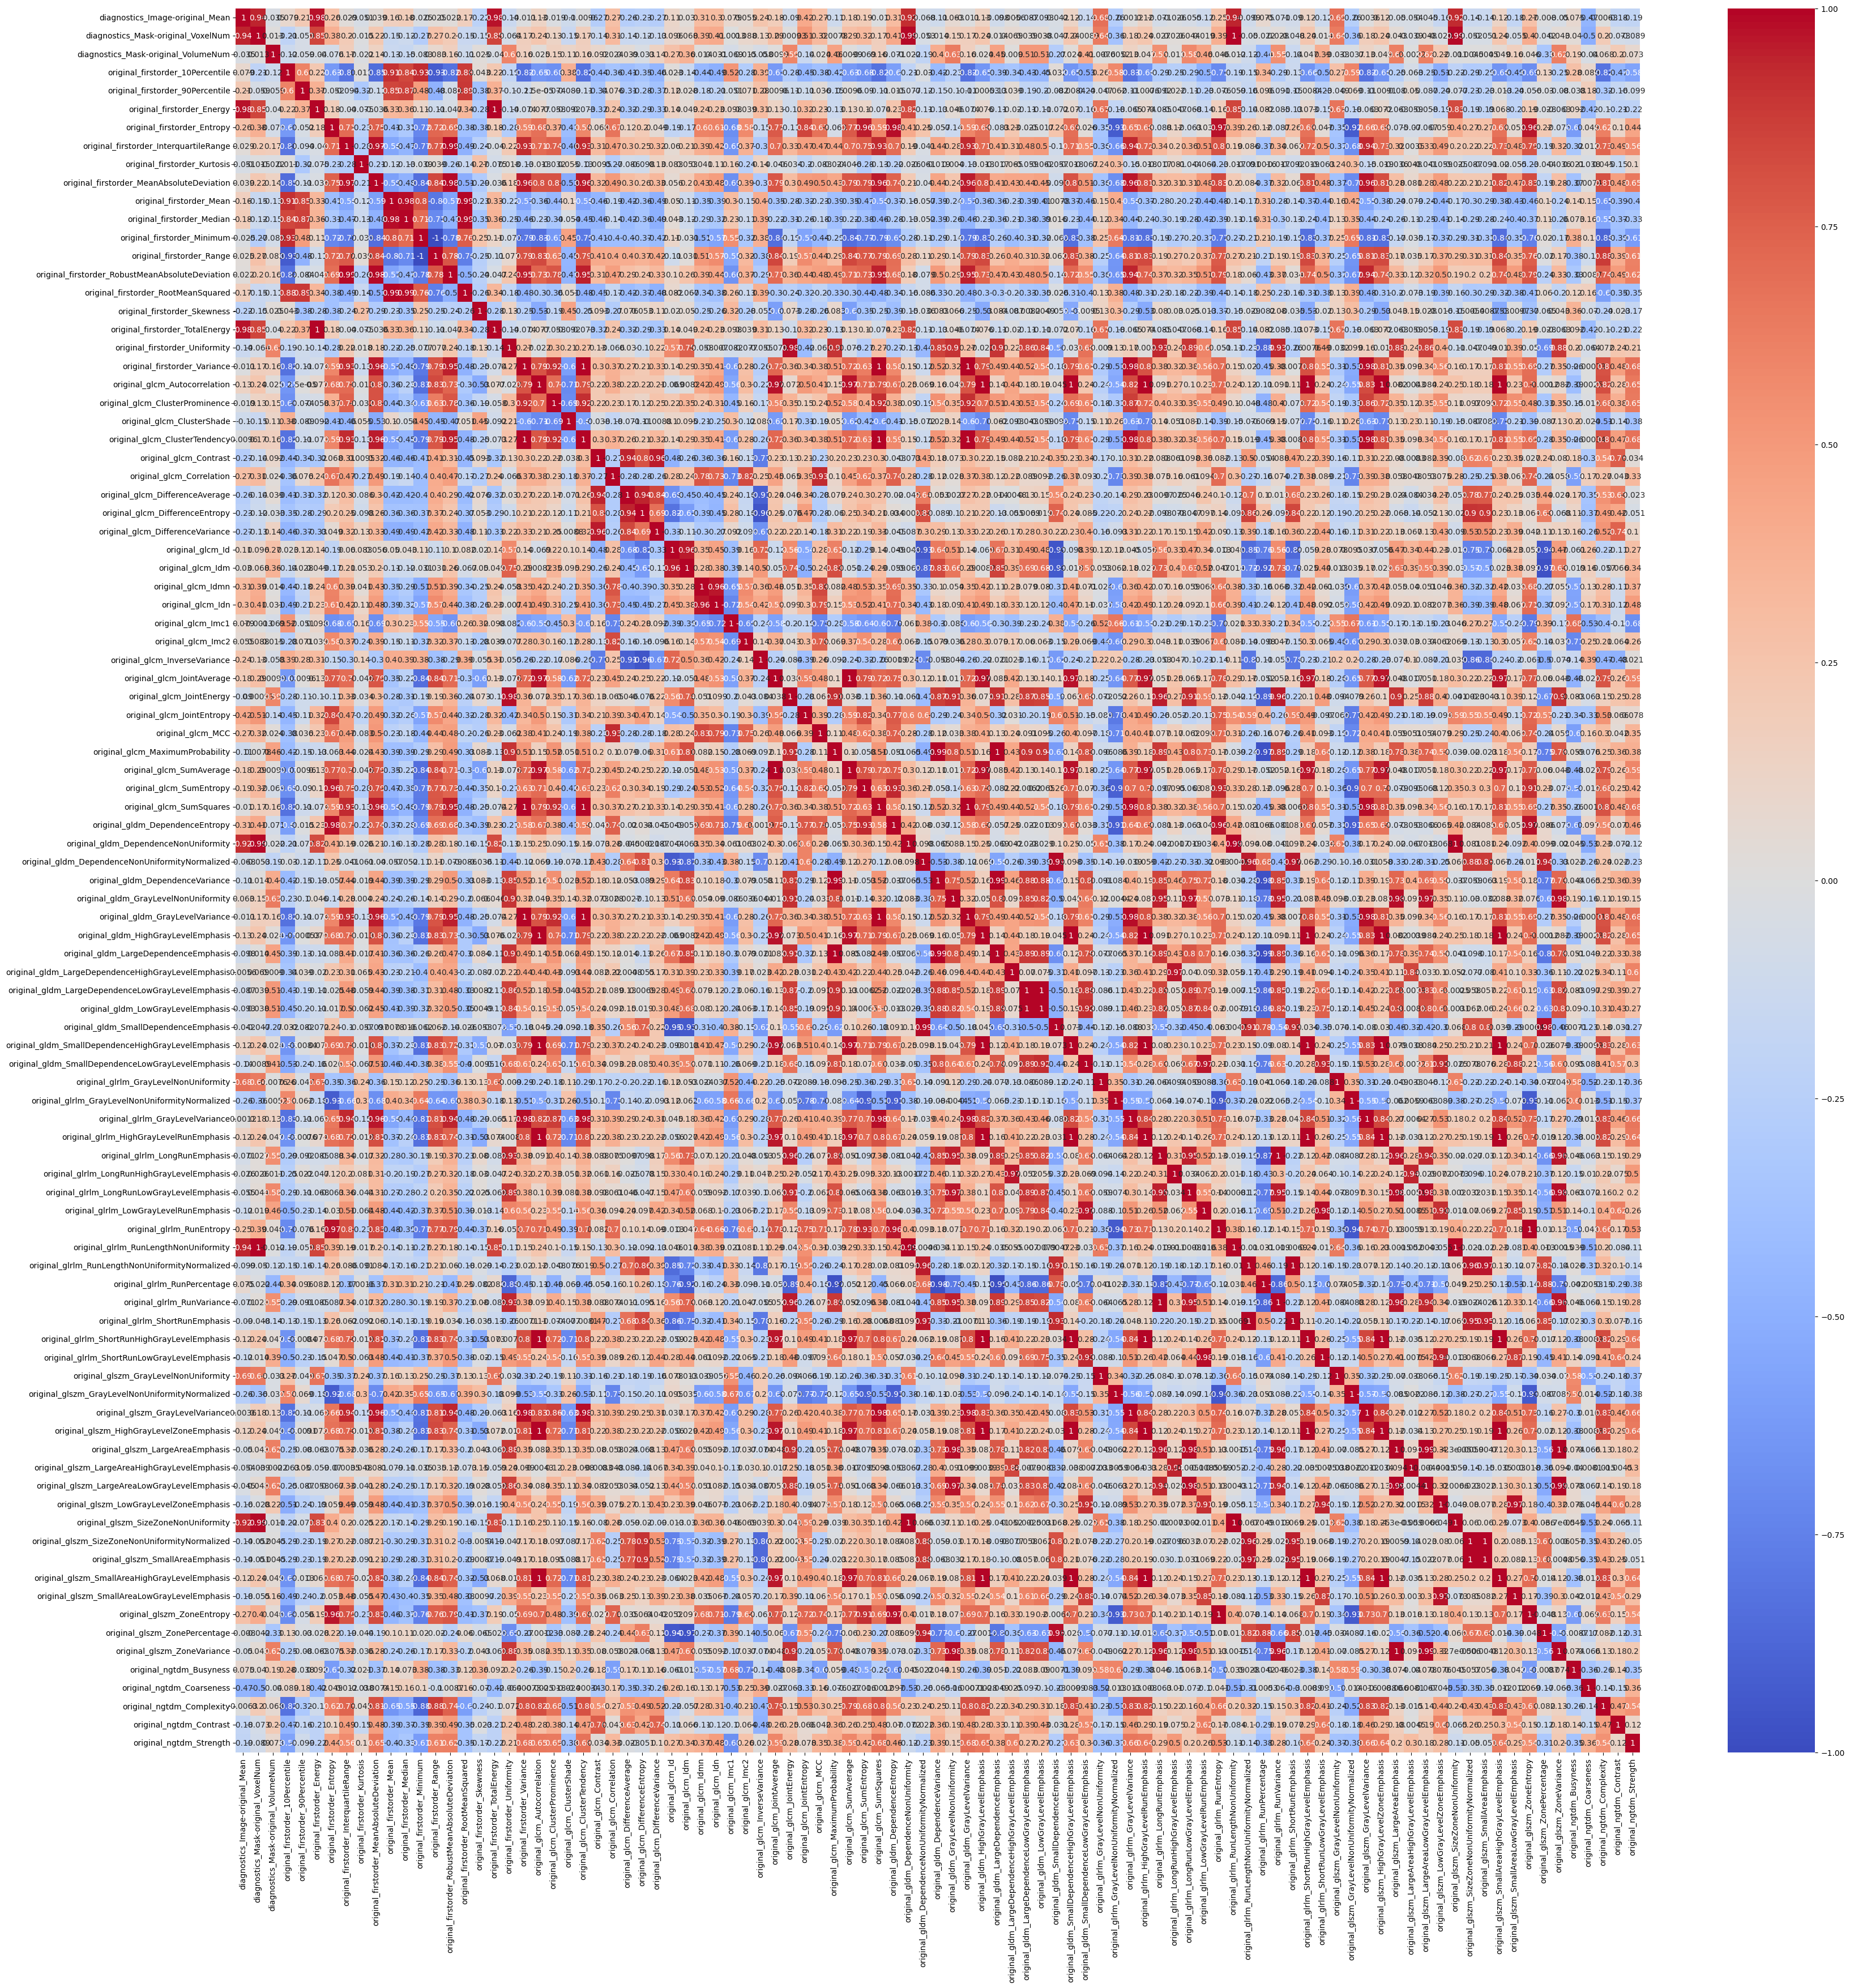

In [281]:
# Construindo a matriz de correlação
plt.figure(figsize=(40,40))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

### O gráfico acima é IMPOSSÍVEL de visualizar, então vamos usar outras técnicas

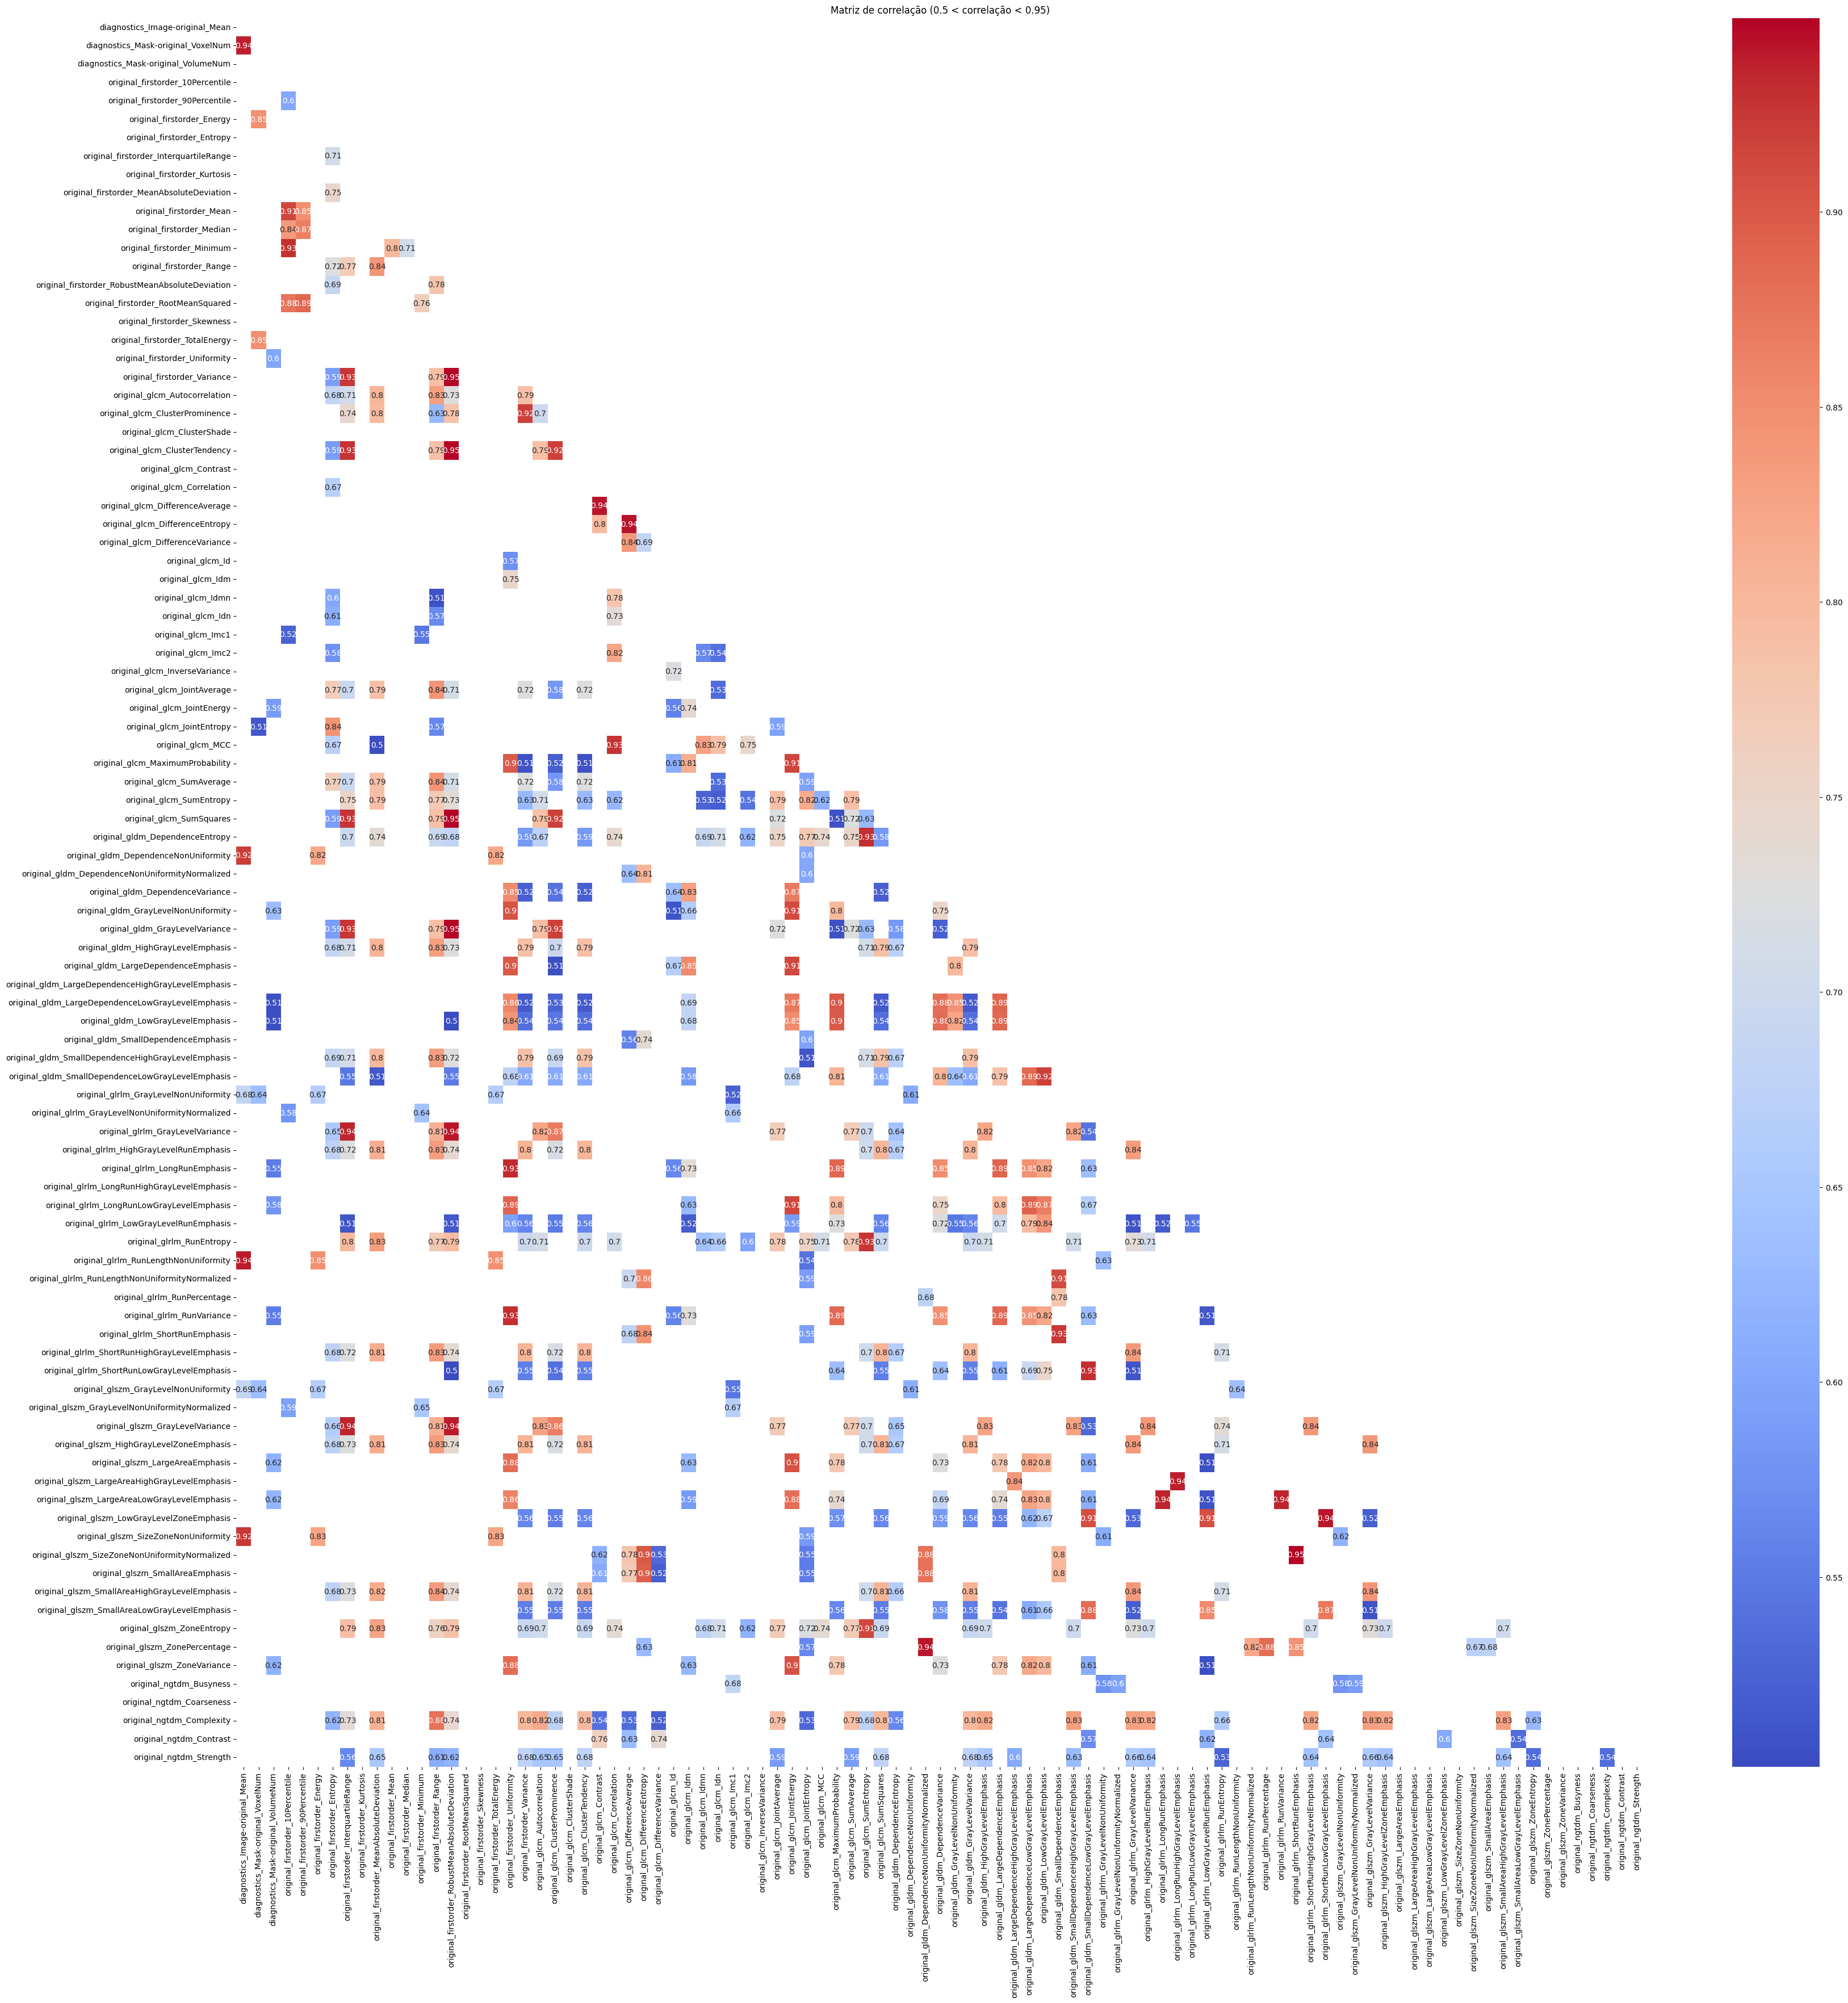

In [282]:
# Construindo a matriz de correlação com filtro
corr_matrix = df.corr()
filtered_corr = corr_matrix[(corr_matrix > 0.5) & (corr_matrix < 0.95)]

# Criando uma máscara para exibir apenas a parte inferior da diagonal
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))

plt.figure(figsize=(40, 40))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', mask=mask)
plt.title('Matriz de correlação (0.5 < correlação < 0.95)')
plt.show()

### Um pouco melhor, mas ainda não está bom.
### Agora vamos fazer uma análise de PCA para ver se conseguimos reduzir o número de features.

In [290]:
# Selecionar as variáveis para PCA (excluindo colunas binárias)
# Identificar colunas binárias (contendo apenas 0 e 1)
binary_cols = [col for col in df.columns if set(df[col].unique()).issubset({0, 1})]
# Selecionar todas as colunas exceto as binárias
X = df.drop(columns=binary_cols)

# Rescaling dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertendo para DataFrame para usar o cov
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Salvando os dados escalados
X_scaled_df.merge(classes, left_index=True, right_index=True).to_csv('data/radiomic_data_scaled.csv', index=False)

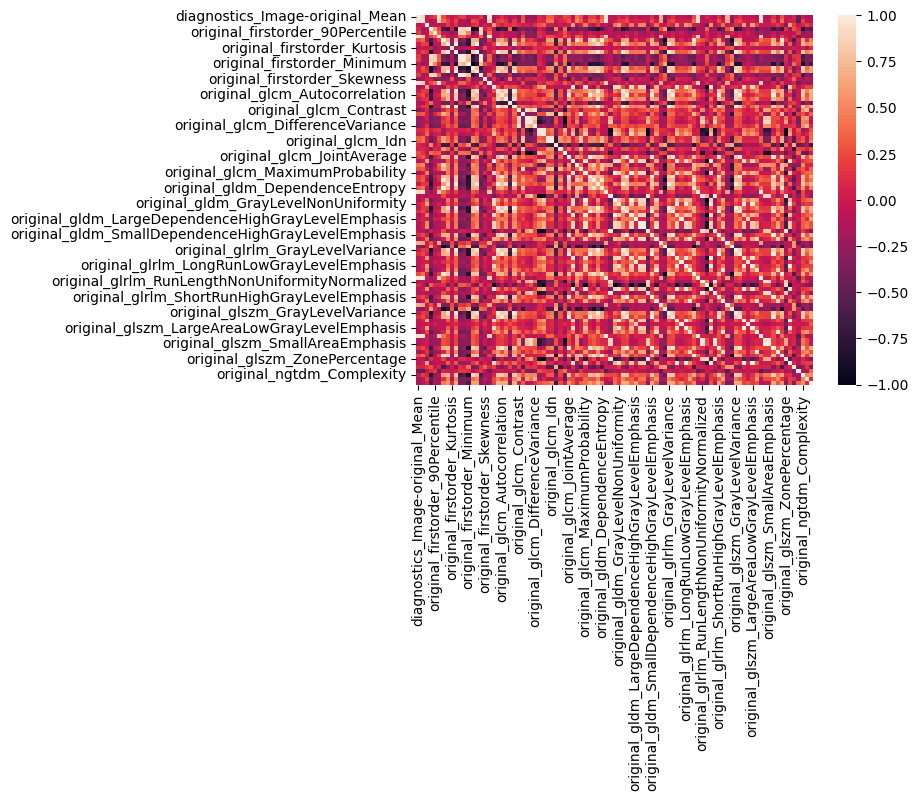

<Figure size 4000x4000 with 0 Axes>

In [284]:
c = X_scaled_df.cov()
sns.heatmap(c)
plt.figure(figsize=(40, 40))
plt.show()

### Agora vamos descobrir quantos componentes iremos utilizar para esse conjunto de dados

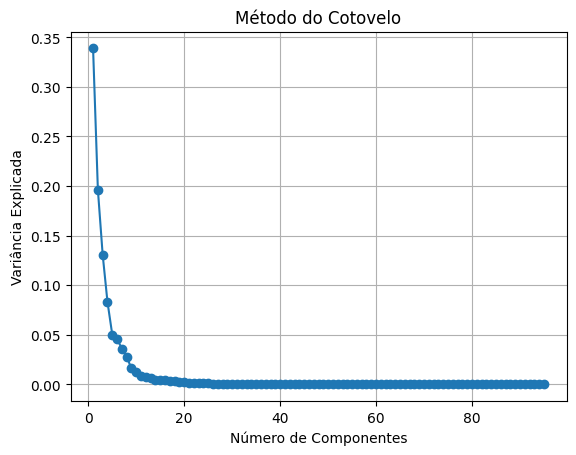

Número de componentes para 90% de variância explicada: 8


In [285]:
# Fazendo a análise usando o método do cotovelo
pca = PCA()

pca.fit(X_scaled_df)
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance_cumulative = np.cumsum(explained_variance_ratio)

plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada')
plt.title('Método do Cotovelo')
plt.grid(True)
plt.show()

components_90 = np.argmax(explained_variance_cumulative >= 0.90) + 1
print(f"Número de componentes para 90% de variância explicada: {components_90}")

In [286]:
# Fazendo a análise usando o método de Kaiser
eigenvalues = pca.explained_variance_
num_components_kaiser = np.sum(eigenvalues > 1)
print(f"Número de componentes com eigenvalue > 1: {num_components_kaiser}")

Número de componentes com eigenvalue > 1: 10


### Para esta análise, irei considerar o método Kaiser
Então, iremos utilizar 10 componentes

### Vamos fazer a redução de dimensão usando o PCA

In [287]:
# Instanciando o PCA
pca = PCA(n_components=10)
pca.fit(df)
df_pca = pca.transform(df)

In [288]:
df_pca = pd.DataFrame(df_pca)

# Substituindo as colunas do df_pca pelo nome das colunas do df
df_pca.columns = [f'PC{i+1}' for i in range(df_pca.shape[1])]
df_pca['class'] = classes
df_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     2018 non-null   float64
 1   PC2     2018 non-null   float64
 2   PC3     2018 non-null   float64
 3   PC4     2018 non-null   float64
 4   PC5     2018 non-null   float64
 5   PC6     2018 non-null   float64
 6   PC7     2018 non-null   float64
 7   PC8     2018 non-null   float64
 8   PC9     2018 non-null   float64
 9   PC10    2018 non-null   float64
 10  class   2018 non-null   object 
dtypes: float64(10), object(1)
memory usage: 173.6+ KB


In [289]:
# Salvando os dados preprocessados
df_pca.to_csv('data/radiomic_data_preprocessed_pca.csv', index=False)